<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-2/YZ50Hafta2Kod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [881]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def __repr__(self):
        return f"Value: {self.data}"

a = Value(5, label='a')
b = Value(3, label='b')
c = a * b
c.label = 'c'
d = Value(2, label='d')
e = Value(-4, label='e')
f = d * e
f.label='f'
g = c + f
g.label='g'
h = Value(-3, label='h')
L = g * h
L.label='L'

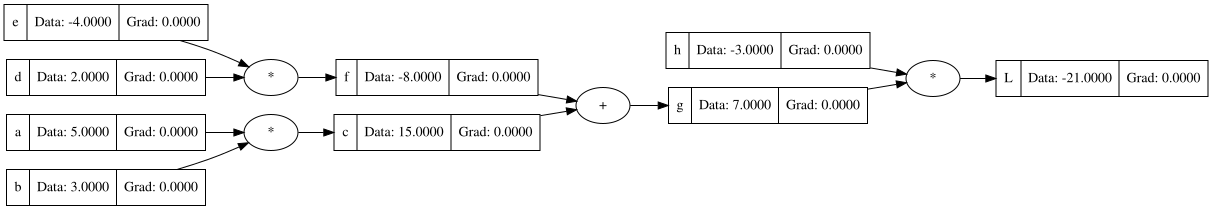

In [882]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v in nodes:
            return
        nodes.add(v)
        for child in v._prev:
            edges.add((v, child))
            build(child)

    build(root)

    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for node in nodes:
        dot.node(name=str(id(node)), label="{%s | Data: %.4f | Grad: %.4f}" % (node.label, node.data, node.grad), shape='record')

        if node._op != '':
            dot.node(name=str(id(node))+'op', label=node._op)
            dot.edge(str(id(node))+'op', str(id(node)))

    for edge in edges:
        dot.edge(str(id(edge[1])), str(id(edge[0]))+'op')

    return dot

draw_dot(L)

In [883]:
# Global turev = lokal turev * zincir kurali carpani

L.grad = 1.0

h.grad = g.data * L.grad
g.grad = h.data * L.grad

f.grad = 1.0 * g.grad
c.grad = 1.0 * g.grad

e.grad = d.data * f.grad
d.grad = e.data * f.grad

b.grad = a.data * c.grad
a.grad = b.data * c.grad

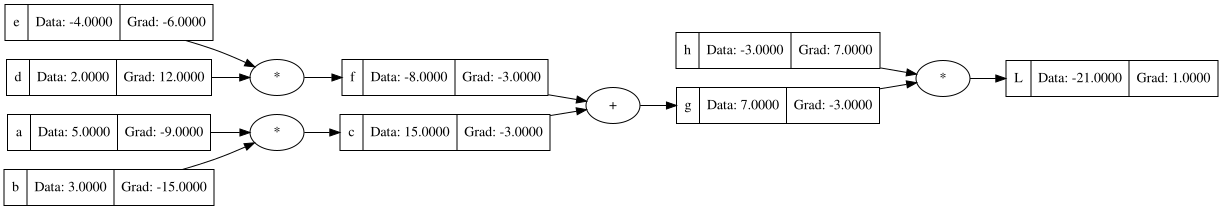

In [884]:
draw_dot(L)

In [885]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def tanh(self):
        num = math.exp(2 * self.data) - 1
        den = num + 2
        out = Value(num / den, _children=(self,), _op='tanh')
        return out

    def __repr__(self):
        return f"Value: {self.data}"

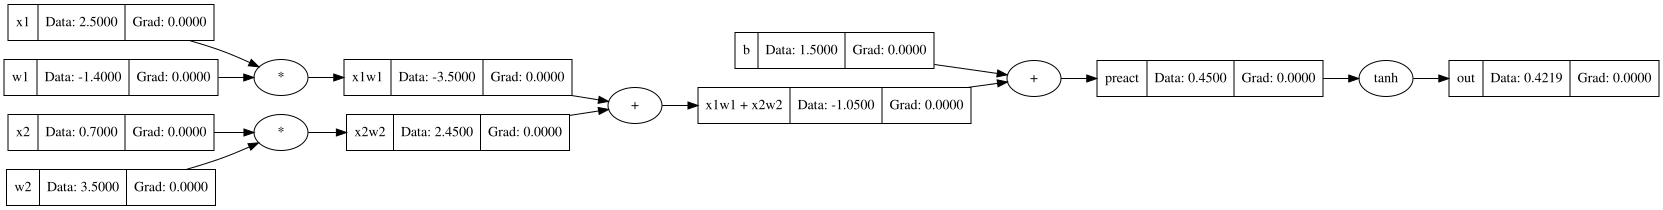

In [886]:
x1 = Value(2.5, label='x1')
x2 = Value(0.7, label='x2')

w1 = Value(-1.4, label='w1')
w2 = Value(3.5, label='w2')

b = Value(1.5, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'

preact = x1w1x2w2 + b
preact.label = 'preact'

output = preact.tanh()
output.label = 'out'

draw_dot(output)

In [887]:
output.grad = 1.0
preact.grad = (1 - output.data**2) * output.grad

x1w1x2w2.grad = 1.0 * preact.grad
b.grad = 1.0 * preact.grad

x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

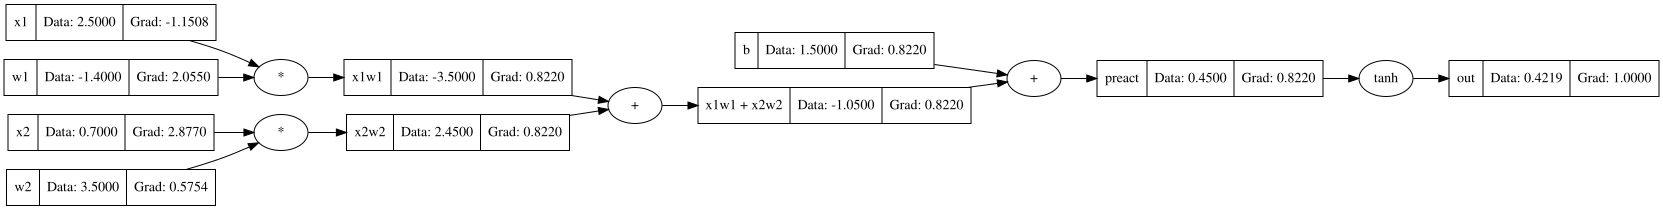

In [888]:
draw_dot(output)

In [889]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        num = math.exp(2 * self.data) - 1
        den = num + 2
        val = num / den
        out = Value(val, _children=(self,), _op='tanh')

        def _backward():
            self.grad += (1 - val**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo_order = []
        marked = set()
        def topo_dfs(node):
            if node in marked:
                return
            for child in node._prev:
                topo_dfs(child)
            topo_order.append(node)
        topo_dfs(self)

        self.grad = 1.0
        for node in reversed(topo_order):
            node._backward()

    def __repr__(self):
        return f"Value: {self.data}"

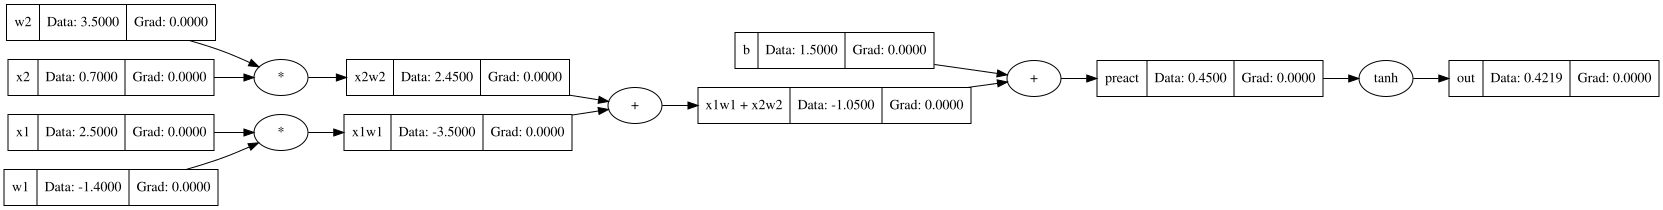

In [890]:
x1 = Value(2.5, label='x1')
x2 = Value(0.7, label='x2')

w1 = Value(-1.4, label='w1')
w2 = Value(3.5, label='w2')

b = Value(1.5, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'

preact = x1w1x2w2 + b
preact.label = 'preact'

output = preact.tanh()
output.label = 'out'

draw_dot(output)

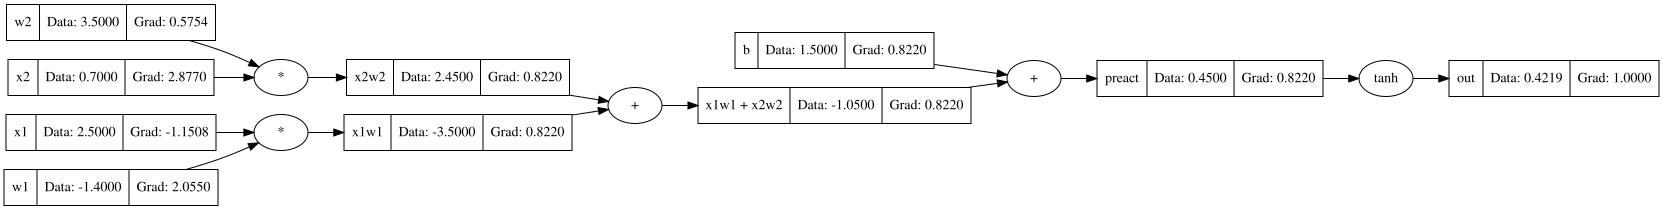

In [891]:
output.backward()

draw_dot(output)

In [892]:
import math

class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op='+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        num = math.exp(2 * self.data) - 1
        den = num + 2
        val = num / den
        out = Value(val, _children=(self,), _op='tanh')

        def _backward():
            self.grad += (1 - val**2) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), _children=(self,), _op='exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "the power type must be int or float"
        out = Value(self.data**other, _children=(self,), _op=f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo_order = []
        marked = set()
        def topo_dfs(node):
            if node in marked:
                return
            marked.add(node)
            for child in node._prev:
                topo_dfs(child)
            topo_order.append(node)
        topo_dfs(self)

        self.grad = 1.0
        for node in reversed(topo_order):
            node._backward()

    def __repr__(self):
        return f"Value: {self.data}"

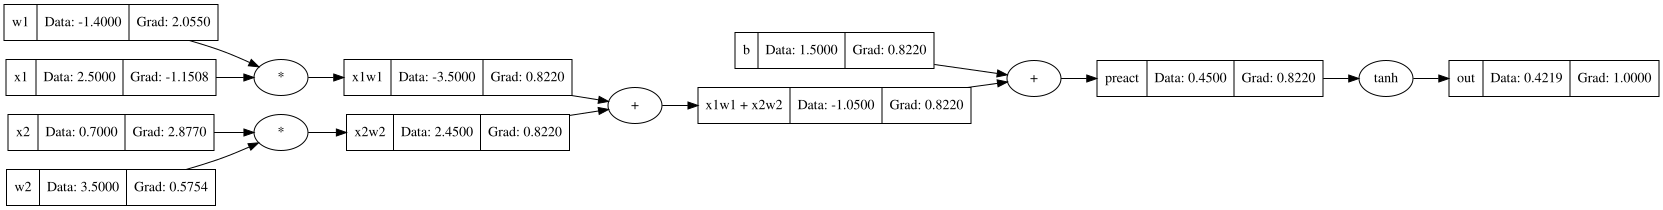

In [893]:
#numerical derivative
x1 = Value(2.5, label='x1')
x2 = Value(0.7, label='x2')
w1 = Value(-1.4, label='w1')
w2 = Value(3.5, label='w2')
b = Value(1.5, label='b')
x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'
preact = x1w1x2w2 + b
preact.label = 'preact'
output = preact.tanh()
output.label = 'out'

output.grad = 1
preact.grad = (1 - output.data**2) * output.grad
x1w1x2w2.grad = 1.0 * preact.grad
b.grad = 1.0 * preact.grad
x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

draw_dot(output)

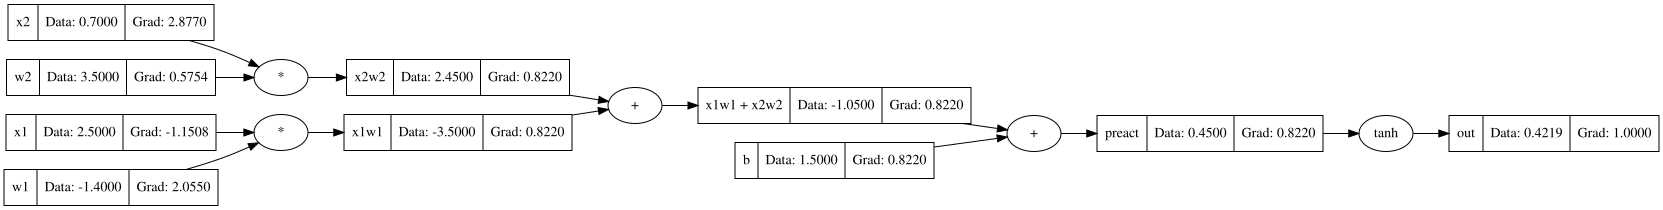

In [894]:
#backward() derivative
x1 = Value(2.5, label='x1')
x2 = Value(0.7, label='x2')

w1 = Value(-1.4, label='w1')
w2 = Value(3.5, label='w2')

b = Value(1.5, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'

preact = x1w1x2w2 + b
preact.label = 'preact'

output = preact.tanh()
output.label = 'out'

output.backward()
draw_dot(output)

In [895]:
#PyTorch derivative
import torch

x1 = torch.tensor([2.5], requires_grad=True)
x2 = torch.tensor([0.7], requires_grad=True)
w1 = torch.tensor([-1.4], requires_grad=True)
w2 = torch.tensor([3.5], requires_grad=True)
b = torch.tensor([1.5], requires_grad=True)
preact = x1*w1 + x2*w2 + b
preact.retain_grad()
output = torch.tanh(preact)
output.retain_grad()

output.backward()
print(f"x1 grad: {x1.grad}")
print(f"w1 grad: {w1.grad}")
print(f"x2 grad: {x2.grad}")
print(f"w2 grad: {w2.grad}")
print(f"b grad: {b.grad}")
print(f"preact grad: {preact.grad}")
print(f"out grad: {output.grad}")

x1 grad: tensor([-1.1508])
w1 grad: tensor([2.0550])
x2 grad: tensor([2.8770])
w2 grad: tensor([0.5754])
b grad: tensor([0.8220])
preact grad: tensor([0.8220])
out grad: tensor([1.])


In [896]:
import random

random.seed(42)

class Neuron:
    def __init__(self, num_in):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(num_in)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, x):
        preact = sum([xi*wi for xi, wi in zip(x, self.weights)], self.bias)
        out = preact.tanh()
        return out

    def parameters(self):
        return self.weights + [self.bias]

class Layer:
    def __init__(self, num_in, num_out):
        self.neurons = [Neuron(num_in) for _ in range(num_out)]

    def __call__(self, x):
        out = [neuron(x) for neuron in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [param for neuron in self.neurons for param in neuron.parameters()]

class MLP:
    def __init__(self, num_in, layer_sizes):
        sz = [num_in] + layer_sizes
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(layer_sizes))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        out = x
        return out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [897]:
x = [2.0, 3.0, -1.0]
model = MLP(3, [4, 4, 1])
model(x)

Value: 0.6994093620224067

In [898]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [899]:
learning_rate = 0.05

epochs = 20

for epoch in range(epochs):
    ypred = [model(x) for x in xs]
    loss = sum((pred - ytrg)**2 for pred, ytrg in zip(ypred, ys))
    print(f"Epoch {epoch} | loss: {loss.data}")

    for p in model.parameters():
        p.grad = 0.0

    loss.backward()

    for p in model.parameters():
        p.data += -learning_rate * p.grad

Epoch 0 | loss: 5.230517512042235
Epoch 1 | loss: 2.704689050764245
Epoch 2 | loss: 1.8460237252314982
Epoch 3 | loss: 1.177487008791908
Epoch 4 | loss: 0.821729455083264
Epoch 5 | loss: 0.5957215587693916
Epoch 6 | loss: 0.43115794091632753
Epoch 7 | loss: 0.3468314917603136
Epoch 8 | loss: 0.28903713992681335
Epoch 9 | loss: 0.2460506558393817
Epoch 10 | loss: 0.2130938981393669
Epoch 11 | loss: 0.18718814718937846
Epoch 12 | loss: 0.16638755353165707
Epoch 13 | loss: 0.14937997337031497
Epoch 14 | loss: 0.1352548466184191
Epoch 15 | loss: 0.1233638954594017
Epoch 16 | loss: 0.11323493741060496
Epoch 17 | loss: 0.10451700918771245
Epoch 18 | loss: 0.0969444902613684
Epoch 19 | loss: 0.09031307448189851
